## Импорт библиотек и настройка инструментов

In [30]:
import pandas as pd
import numpy as np

# Инструменты для пайплайна и валидации
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# Инструменты предобработки
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Модель классификации
from sklearn.neighbors import KNeighborsClassifier

# Бизнес-метрики качества
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

## Загрузка и очистка данных

In [37]:
df = pd.read_csv("Telco-Customer-Churn.csv")

df = df.drop("customerID", axis=1)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

class_counts = df["Churn"].value_counts(normalize=True) * 100
print(f"Баланс классов:\nНе ушли - {class_counts[0]:.1f}%\nУшли - {class_counts[1]:.1f}%")
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(df.columns)

Баланс классов:
Не ушли - 73.5%
Ушли - 26.5%
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


удаление уникального идентификатора, приведение TotalCharges к числовому типу с заполнением нулями в случае пропуска, Churn -> бинарный формат

## Пайплайн предобработки

In [38]:
numeric_features = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod']

# Ветка 1: Обработка чисел
numeric_transformer = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median")),
           ("scaler", StandardScaler())]
)

# Ветка 2: Обработка категорий (текста)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

# 1 + 2
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)
# Итоговый конвейер: Предобработка -> Модель
clf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier())
    ]
)

param_grid = {
    "classifier__n_neighbors": [3,5,9],
    "classifier__weights":["uniform", "distance"]
}

# 5-fold кросс-валидация
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# сбор всего в одно
grid_search = GridSearchCV(
    estimator=clf_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
print(f"Лучшие параметры алгоритма: {grid_search.best_params_}")

Лучшие параметры алгоритма: {'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}


## Оценка качества классификации

In [ ]:
# 0 1 
y_pred = best_model.predict(X_test)

y_proba = best_model.predict_proba(X_test)[:,1]

print("--- Матрица ошибок ---")
conf_matrix = confusion_matrix(y_test,y_pred)

print(f"истинно отрицательные(TN - клиент не ушел, предсказали что остался){conf_matrix[0][0]}")
print(f"ложноположительные(FP - клиент не ушел, предсказали что уйдет ){conf_matrix[0][1]}")
print(f"ложноотрицательные(FN - клиент ушел, предсказали что остался){conf_matrix[1][0]}")
print(f"истинно положительные(TP - клиент ушел, предсказали что уйдет){conf_matrix[1][1]}")

print("--- Отчет по метрикам ---")
print(classification_report(y_test, y_pred, target_names=["Хороший(0)", "Дефолт(1)"]))

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Площадь под кривой ROC-AUC: {roc_auc:.4f}")

--- Матрица ошибок ---
истинно отрицательные(TN - клиент не ушел, предсказали что остался)880
ложноположительные(FP - клиент не ушел, предсказали что уйдет )155
ложноотрицательные(FN - клиент ушел, предсказали что остался)155
истинно положительные(TP - клиент ушел, предсказали что уйдет)219
--- Отчет по метрикам ---
              precision    recall  f1-score   support

  Хороший(0)       0.85      0.85      0.85      1035
   Дефолт(1)       0.59      0.59      0.59       374

    accuracy                           0.78      1409
   macro avg       0.72      0.72      0.72      1409
weighted avg       0.78      0.78      0.78      1409

Площадь под кривой ROC-AUC: 0.8134


In [40]:
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

## Определение лучших параметров

In [78]:

df_reg = df.dropna(subset=['TotalCharges']).copy()
X_reg = df_reg[["tenure", 'SeniorCitizen']]
y_reg = df_reg["TotalCharges"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

reg_pipeline = Pipeline(
    [("scaler", StandardScaler()), ("knn_reg", KNeighborsRegressor())]
)
kf = KFold(n_splits=5, shuffle=True, random_state=42)
param_dist = {
    "knn_reg__n_neighbors": np.arange(3,30),
    "knn_reg__weights": ["uniform", "distance"]
}
random_search = RandomizedSearchCV(
    estimator=reg_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=kf,
    scoring='neg_mean_absolute_error',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_r, y_train_r)
best_reg = random_search.best_estimator_
print(f"Лучшие параметры алгоритма: {random_search.best_params_}")

Лучшие параметры алгоритма: {'knn_reg__weights': 'uniform', 'knn_reg__n_neighbors': np.int64(29)}


## Метрики регрессии

In [79]:
y_pred_r = best_reg.predict(X_test_r)
def smape(y_test, y_pred):
    return 100* np.mean(
        2 * np.abs(y_pred-y_test)/(np.abs(y_test)+np.abs(y_pred))
    )
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_r, y_pred_r)
smape_value = smape(y_test_r, y_pred_r)

print("--- Отчет по метрикам регрессии ---")
print(f"MSE (квадратные $) {mse:.0f}")
print(f"RMSE ($) {rmse:.0f}")
print(f"MAE (Средняя ошибка) {mae:.2f}")
print(f"SMAPE (ошибка в %) {smape_value:.2f}%")

--- Отчет по метрикам регрессии ---
MSE (квадратные $) 1702537
RMSE ($) 1305
MAE (Средняя ошибка) 848.12
SMAPE (ошибка в %) 43.80%


## Визуализация результатов 

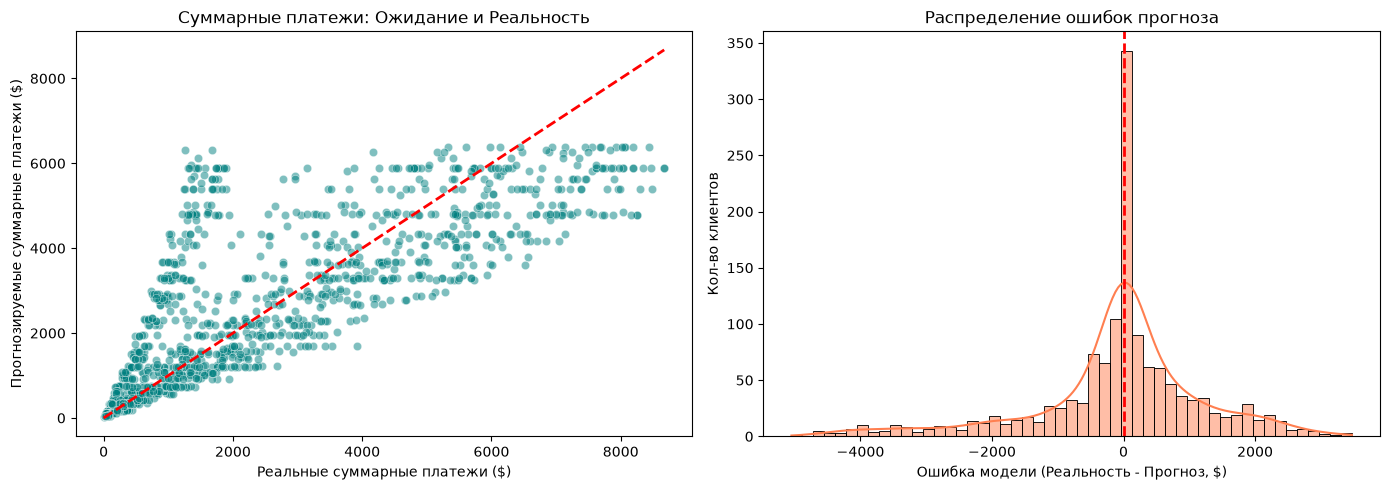

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1,2, figsize=(14,5))

# 1 график: Факт vs Прогноз
sns.scatterplot(x=y_test_r, y=y_pred_r, alpha=0.5, color="teal", ax=axes[0])
y_min= min(y_test_r.min(), y_pred_r.min())
y_max= max(y_test_r.max(), y_pred_r.max())
axes[0].plot(
    [y_min, y_max], [y_min, y_max], 'r--', lw=2
)
axes[0].set_title("Суммарные платежи: Ожидание и Реальность")
axes[0].set_xlabel("Реальные суммарные платежи ($)")
axes[0].set_ylabel("Прогнозируемые суммарные платежи ($)")

# 2 график: Распределение ошибок
residuals = y_test_r - y_pred_r
sns.histplot(residuals, kde=True, color='coral', ax=axes[1])
axes[1].axvline(x=0, color='red', linestyle='--', lw=2) # линия нулевой ошибки
axes[1].set_title("Распределение ошибок прогноза")
axes[1].set_xlabel("Ошибка модели (Реальность - Прогноз, $)")
axes[1].set_ylabel("Кол-во клиентов")

plt.tight_layout()
plt.show()